In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def visualize_yolo_segmentation(image_name):
    base_name = image_name.replace(".png", "")
    img_path = os.path.join("BUSI_division/images", image_name)
    txt_path = os.path.join("BUSI_division/labels", base_name + "_mask.txt")
    mask_path = os.path.join("BUSI_division/masks", base_name + "_mask.png")
    
    # Carrega a imagem original
    img = cv2.imread(img_path)
    if img is None:
        print(f"Imagem {img_path} não encontrada.")
        return
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    img_with_polygons = img.copy()
    
    # Lê as coordenadas do txt (YOLO format)
    if os.path.exists(txt_path):
        with open(txt_path, "r") as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) > 1:
                    class_id = int(parts[0])
                    # Extrai os pares (x, y) e converte de volta para a resolução original
                    coords = np.array(parts[1:], dtype=np.float32).reshape(-1, 2)
                    coords[:, 0] *= w # multiplicando x pela largura
                    coords[:, 1] *= h # multiplicando y pela altura
                    
                    pts = np.int32(coords)
                    
                    # Contorno do polígono
                    cv2.polylines(img_with_polygons, [pts], isClosed=True, color=(255, 0, 0), thickness=2)
                    
                    # Preenchimento transparente
                    overlay = img_with_polygons.copy()
                    cv2.fillPoly(overlay, [pts], color=(255, 0, 0))
                    cv2.addWeighted(overlay, 0.4, img_with_polygons, 0.6, 0, img_with_polygons)
    else:
        print(f"Arquivo txt {txt_path} não encontrado ou vazio.")

    # Carrega a máscara original
    if os.path.exists(mask_path):
        mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    else:
        mask_img = np.zeros((h, w), dtype=np.uint8)
        
    # Mostra usando matplotlib
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis('off')
    
    axes[1].imshow(img_with_polygons)
    axes[1].set_title("Segmentação YOLO (OpenCV)")
    axes[1].axis('off')
    
    axes[2].imshow(mask_img, cmap='gray')
    axes[2].set_title("Máscara Original")
    axes[2].axis('off')
    
    plt.show()


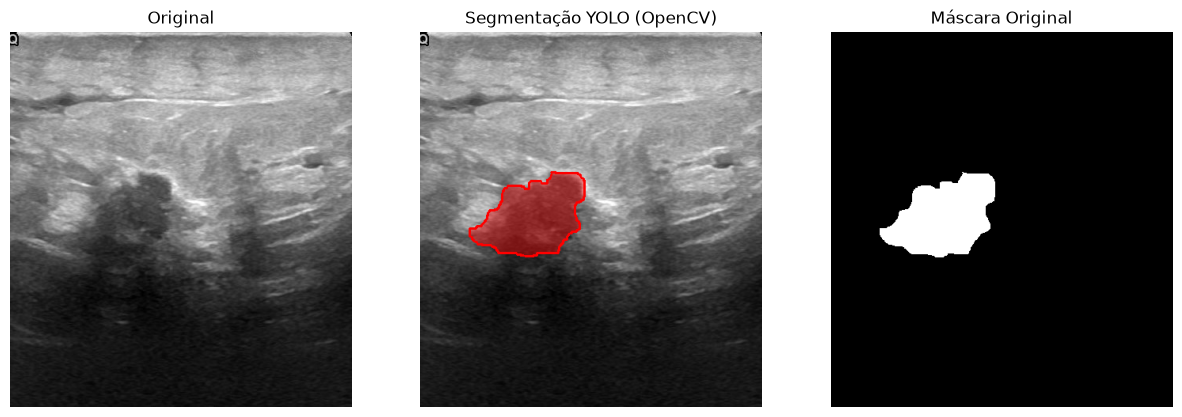

In [3]:
# Testando a função com uma imagem benigna
visualize_yolo_segmentation("malignant (7).png")
